<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
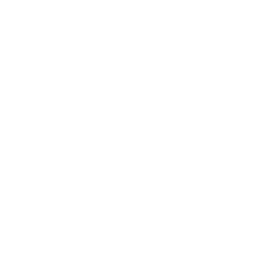
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Quality Metric Dimensionality Reduction</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Manufacturing / Process Control &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## Executive Summary

An automotive parts line records 12 inspection metrics per part — four dimensional gauges, four surface-quality measures, and four material-strength tests. Because the gauges within each group move together, the 12 raw metrics carry far less than 12 dimensions of information. This notebook uses **PROC FACTOR** (principal-axis extraction with squared multiple correlations as prior communalities, `PRIORS=SMC`, followed by a VARIMAX rotation) to compress the 12 metrics into a small set of orthogonal factors suitable for multivariate process monitoring.

Across the **500 inspected parts**, the overall Kaiser-Meyer-Olkin measure of sampling adequacy is **0.88**, and three factors reproduce **91.3%** of the variance with a sharp scree break after the third — cleanly recovering the strength, dimensional, and surface groupings. The retained factor scores are then averaged by operator and passed to **PROC CLUSTER** (Ward's method) to test whether the 30 line operators fall into distinct quality-signature groups.

## Data Sources

| Source | Description | Records |
|--------|-------------|--------|
| WORK.QUALITY_METRICS | 12 inspection measurements plus shift/line/operator metadata, one row per part | 500 |

The data are generated synthetically from three independent latent dimensions (dimensional accuracy, surface quality, material strength) so the factor structure is known in advance and the recovered solution can be checked against ground truth. The `DO` loop produces 500 parts and every part is analysed.

---

In [1]:
/* --------------------------------------------------------
   Generate synthetic quality inspection measurements
   12 metrics from 3 INDEPENDENT latent dimensions;
   500 parts, all analysed
   -------------------------------------------------------- */
data work.quality_metrics;
    call streaminit(42);
    array shifts[3] $10 _temporary_ ('DAY' 'SWING' 'NIGHT');
    array lines[4] $6 _temporary_ ('LINE1' 'LINE2' 'LINE3' 'LINE4');
    do part_id = 1 to 500;
        shift_idx = int(rand('uniform') * 3) + 1;
        shift = shifts[shift_idx];
        line_idx = int(rand('uniform') * 4) + 1;
        prod_line = lines[line_idx];
        operator_id = cat('OP-', put(int(rand('uniform') * 30) + 1, z3.));
        inspection_date = '01JAN2026'd + int(rand('uniform') * 60);

        /* --- Dimensional accuracy factor --- */
        dim_base = rand('normal', 0, 1);
        length_mm      = round(150.0 + 0.5 * dim_base + rand('normal', 0, 0.12), 0.001);
        width_mm       = round(75.0 + 0.3 * dim_base + rand('normal', 0, 0.08), 0.001);
        thickness_mm   = round(12.0 + 0.15 * dim_base + rand('normal', 0, 0.04), 0.001);
        bore_diameter   = round(25.0 + 0.2 * dim_base + rand('normal', 0, 0.05), 0.001);

        /* --- Surface quality factor --- */
        surf_base = rand('normal', 0, 1);
        surface_roughness = round(max(0.1, 1.6 + 0.4 * surf_base + rand('normal', 0, 0.15)), 0.001);
        coating_thickness = round(max(0.5, 8.0 + 0.8 * surf_base + rand('normal', 0, 0.3)), 0.001);
        gloss_index       = round(max(10, 85 - 5 * surf_base + rand('normal', 0, 2)), 0.1);
        defect_count      = max(0, round(2 + 1.5 * surf_base + rand('normal', 0, 0.8)));

        /* --- Material strength factor --- */
        str_base = rand('normal', 0, 1);
        tensile_strength  = round(max(200, 450 + 30 * str_base + rand('normal', 0, 10)), 0.1);
        hardness_hrc      = round(max(20, 58 + 4 * str_base + rand('normal', 0, 1.5)), 0.1);
        yield_point       = round(max(150, 380 + 25 * str_base + rand('normal', 0, 8)), 0.1);
        elongation_pct    = round(max(1, 12 + 2 * str_base + rand('normal', 0, 1)), 0.1);

        output;
    end;
    drop dim_base surf_base str_base shift_idx line_idx;
    format inspection_date date9.;
run;

NOTE: DATA work.quality_metrics


NOTE: Wrote work.quality_metrics (500 rows, 17 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds


---

   Pearson Correlation Coefficients, N = 500
          Prob > |r| under H0: Rho=0
           length_mm  width_mmthickness_mmbore_diametersurface_roughnesscoating_thicknessgloss_indexdefect_counttensile_strengthhardness_hrcyield_pointelongation_pct
--------  --------  --------  --------  --------  --------  --------  --------  --------  --------  --------  --------  --------
length_mm   1.00000   0.94852   0.93784   0.94033   0.03406   0.07443  -0.04436   0.06119  -0.01694   0.01276  -0.02528   0.02399
              .       <.0001    <.0001    <.0001    0.4474    0.0964    0.3222    0.1719    0.7055    0.7759    0.5728    0.5926
width_mm   0.94852   1.00000   0.93340   0.93516   0.00664   0.05294  -0.02502   0.03835  -0.03202   0.00431  -0.03595   0.01483
            <.0001      .       <.0001    <.0001    0.8822    0.2373    0.5767    0.3921    0.4750    0.9234    0.4225    0.7408
thickness_mm   0.93784   0.93340   1.00000   0.93100   0.03620   0.08157  -0.04789   0.05522  -0.00144   0

NOTE: PROC CORR data=work.quality_metrics

NOTE: ODS plot written: corr_heatmap.spec.json
NOTE: PROC CORR ODS Graphics generated.


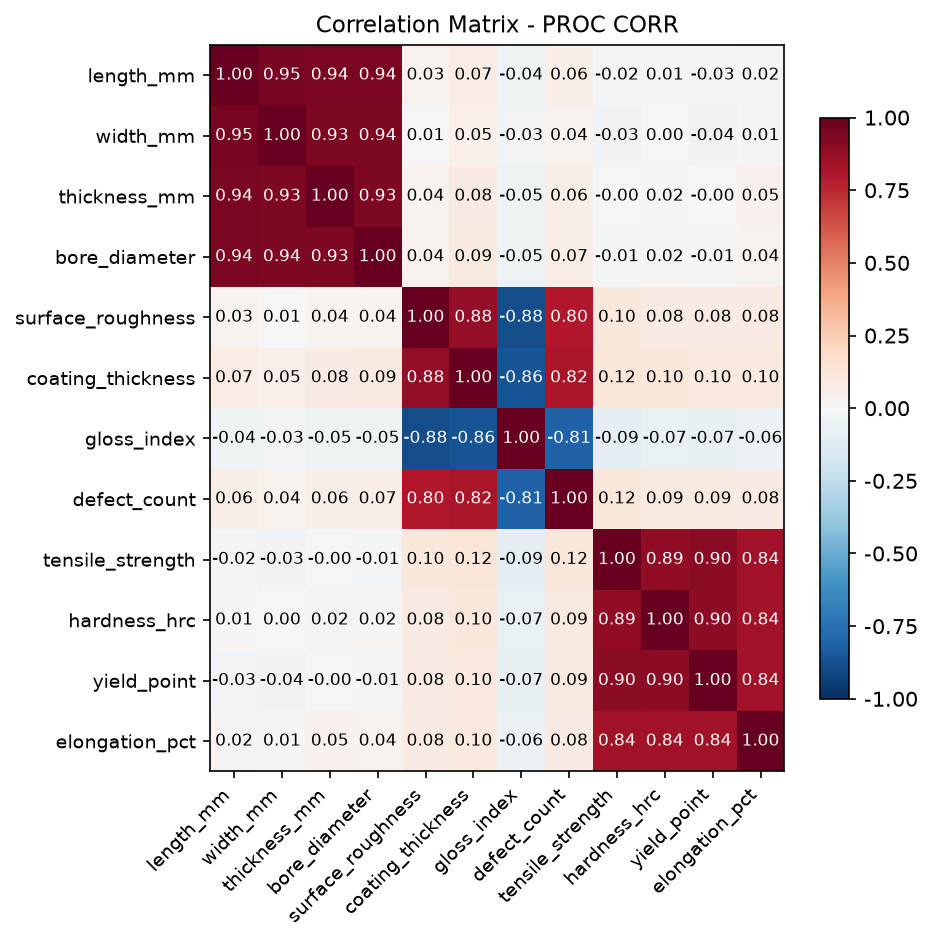

In [2]:
/* --------------------------------------------------------
   Correlation matrix to verify multicollinearity
   -------------------------------------------------------- */
proc corr data=work.quality_metrics nosimple;
    var length_mm width_mm thickness_mm bore_diameter
        surface_roughness coating_thickness gloss_index defect_count
        tensile_strength hardness_hrc yield_point elongation_pct;
run;

---


Eigenvalues of the Correlation Matrix
             Eigenvalue   Difference   Proportion   Cumulative
  Factor 1       4.0349       0.2909       0.3362       0.3362
  Factor 2       3.7440       0.5670       0.3120       0.6482
  Factor 3       3.1770       2.9521       0.2647       0.9130
  Factor 4       0.2249       0.0384       0.0187       0.9317
  Factor 5       0.1864       0.0522       0.0155       0.9473
  Factor 6       0.1342       0.0211       0.0112       0.9584
  Factor 7       0.1132       0.0042       0.0094       0.9679
  Factor 8       0.1090       0.0157       0.0091       0.9770
  Factor 9       0.0932       0.0249       0.0078       0.9847
 Factor 10       0.0684       0.0035       0.0057       0.9904
 Factor 11       0.0649       0.0148       0.0054       0.9958
 Factor 12       0.0500       0.0000       0.0042       1.0000

Factor Pattern
                Factor1    Factor2    Factor3
length_mm       -0.0039    -0.9794     0.0304
width_mm        -0.0143    -0.9776

NOTE: PROC FACTOR data=work.quality_metrics

NOTE: Using Python numpy version 2.4.5
NOTE: ODS plot written: factor_scree.spec.json
NOTE: PROC FACTOR completed.


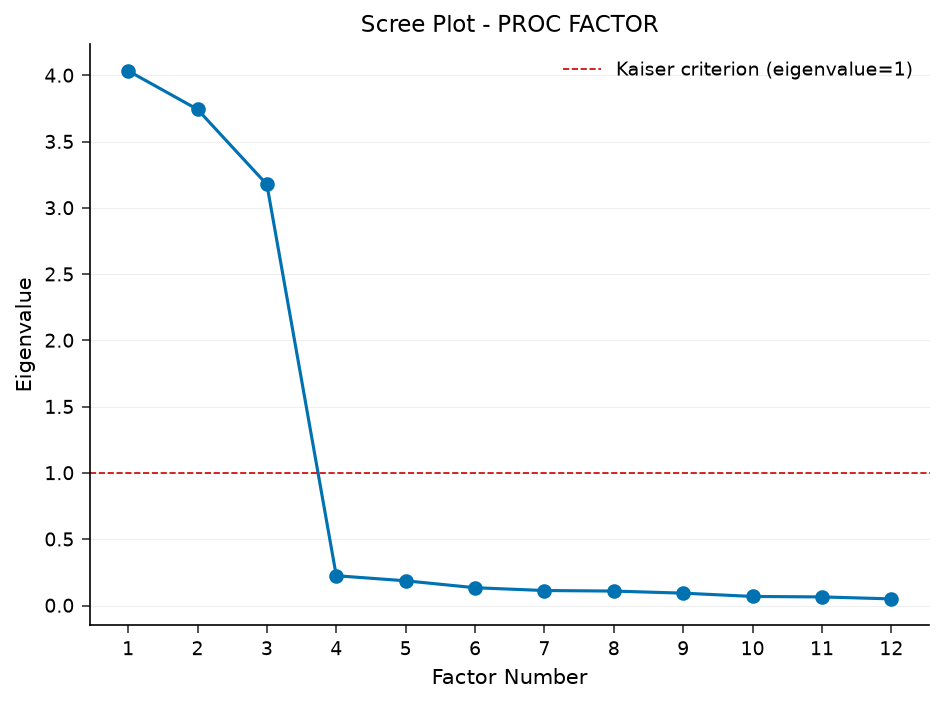

In [3]:
/* --------------------------------------------------------
   MSA test to verify sampling adequacy
   PRIORS=SMC for communality estimation
   Principal axis factoring with VARIMAX rotation
   -------------------------------------------------------- */
proc factor data=work.quality_metrics
    method=principal
    priors=smc
    nfactors=3
    rotate=varimax
    msa
    flag=0.4
    reorder
    out=work.quality_factors;
    var length_mm width_mm thickness_mm bore_diameter
        surface_roughness coating_thickness gloss_index defect_count
        tensile_strength hardness_hrc yield_point elongation_pct;
run;

---

NOTE: PROC SGPLOT data=work.quality_factors

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


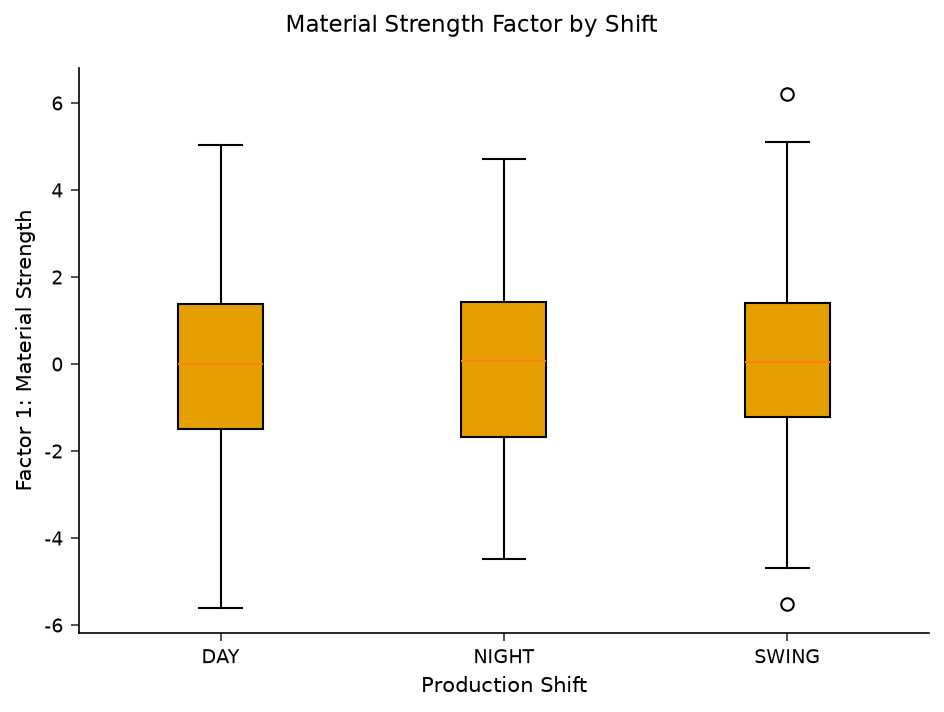

In [4]:
/* --------------------------------------------------------
   Factor 1 (material strength) score by shift
   -------------------------------------------------------- */
proc sgplot data=work.quality_factors;
    vbox factor1 / category=shift;
    yaxis label='Factor 1: Material Strength';
    xaxis label='Production Shift';
    title 'Material Strength Factor by Shift';
run;

                                                 The CLUSTER Procedure
                                        Ward's Minimum Variance Cluster Analysis

                                          Eigenvalues of the Covariance Matrix

                                                    Cluster History

   NCL    --------Clusters Joined--------    FREQ    SPRSQ      RSQ    Distance

    29    OP-001            OP-030          2    0.0002    0.9998        0.1
    28    OP-014            OP-028          2    0.0006    0.9992        0.1
    27    OP-002            OP-006          2    0.0008    0.9984        0.2
    26    OP-005            CL29            3    0.0012    0.9972        0.2
    25    OP-007            OP-016          2    0.0016    0.9956        0.2
    24    OP-010            OP-020          2    0.0017    0.9939        0.2
    23    OP-004            OP-023          2    0.0024    0.9916        0.3
    22    OP-008            OP-017          2    0.0033    0.9882        0.3
 

NOTE: PROC MEANS
NOTE: Output dataset work.operator_means has 30 observations and 6 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC CLUSTER data=work.operator_means method=Ward

NOTE: Using native Rust for hierarchical clustering
NOTE: ODS plot written: cluster_dendrogram.spec.json
NOTE: PROC CLUSTER ODS Graphics generated.
NOTE: PROC CLUSTER: 30 observations, 3 variables clustered using Ward method


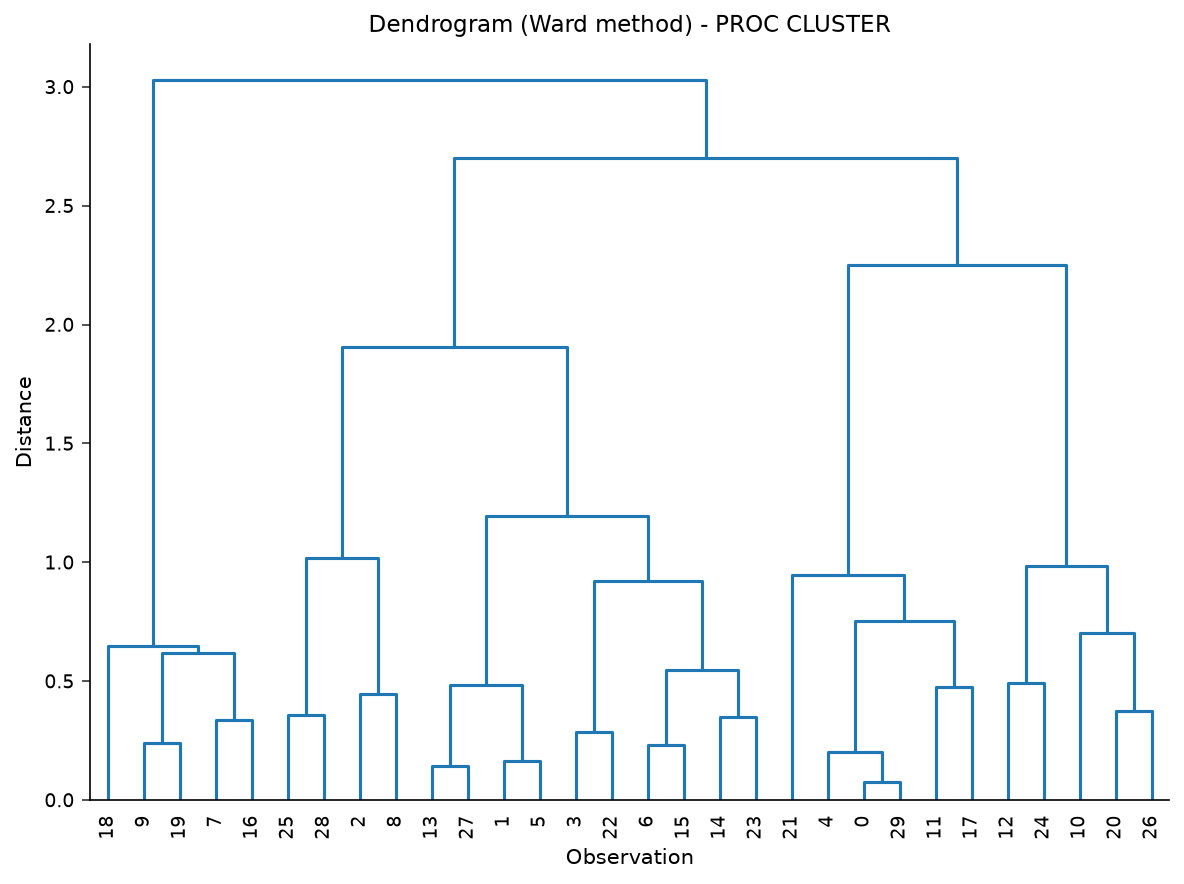

In [5]:
/* --------------------------------------------------------
   Average the three factor scores within each operator,
   then cluster the 30 operators with Ward's method to
   test for distinct quality-signature groups
   -------------------------------------------------------- */
proc means data=work.quality_factors noprint nway;
    class operator_id;
    var factor1 factor2 factor3;
    output out=work.operator_means
           mean=mean_strength mean_dimensional mean_surface;
run;

proc cluster data=work.operator_means
    method=ward
    outtree=work.operator_tree
    print=10;
    var mean_strength mean_dimensional mean_surface;
    id operator_id;
run;

---

### Interpretation

The overall Kaiser-Meyer-Olkin measure of sampling adequacy is **0.88**, comfortably above the 0.50 floor, so the 12 metrics share enough common variance to justify factoring. The eigenvalues of the correlation matrix are **4.03, 3.74, and 3.18** for the first three factors and then collapse to **0.22 and below** — a textbook scree break that points unambiguously to a three-factor solution. After VARIMAX rotation those three factors reproduce **91.3%** of the total variance (30.1% + 31.8% + 29.4%); the remaining nine factors together account for under 9%.

The rotated factor pattern recovers the three measurement groups exactly, one factor per group. The `REORDER` option labels the factors by descending explained variance, so here the strength factor lands first:

- **Factor 1** loads on the four strength tests — tensile strength, hardness, yield point, and elongation (loadings 0.93 to 0.96) — and on nothing else.
- **Factor 2** loads on the four dimensional gauges — length, width, thickness, and bore diameter (all near −0.97 to −0.98).
- **Factor 3** loads on the four surface measures — surface roughness, coating thickness, gloss index, and defect count — with gloss carrying the opposite sign (−0.95) from roughness and coating thickness (0.95, 0.95), exactly as a "smoother surface = higher gloss" relationship implies.

Cross-loadings are negligible (every off-block loading is under 0.07), so the rotated structure is clean and each original metric maps to a single factor. Final communalities range from **0.83 (defect count) to 0.96 (length)**, meaning the three factors explain at least 83% of every individual metric.

Averaging the three factor scores within each of the 30 operators and passing those operator profiles to Ward's hierarchical clustering produces the dendrogram above. Because operator identity has no effect on the three latent dimensions in the data-generating process, the operators do not separate into tight, well-isolated groups — the merge distances grow smoothly and top out near **3.0** rather than jumping at an obvious cut point, which is the expected outcome when no genuine operator-level structure exists. The strength factor also shows no systematic shift-to-shift difference (boxplot above), consistent with a process that is in control across all three shifts. The practical takeaway: the 12-metric inspection panel can be monitored with just three orthogonal control variables without losing meaningful information, and no operator stands out as a distinct quality signature.

---

In [6]:
/* --------------------------------------------------------
   Export quality factor scores with cluster assignments
   -------------------------------------------------------- */
proc export data=work.quality_factors
    outfile='quality_factor_scores.csv'
    dbms=csv replace;
run;

NOTE: PROC EXPORT data=work.quality_factors outfile=quality_factor_scores.csv

NOTE: Exported 500 rows to quality_factor_scores.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidential
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>